In [140]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/data.csv')

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [141]:
"""
    Making Data Consistent, as some columns contain uppercases and lowercases and other underscores
"""

df.columns = df.columns.str.lower().str.replace(' ', '_') 

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [142]:
"""
    Making all columns of type str into consistent values 
"""

strings = list(df.dtypes[df.dtypes == 'str'].index )

strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [143]:
for col in strings:
    df[col] = df[col] .str.lower().str.replace(' ', '_') 

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

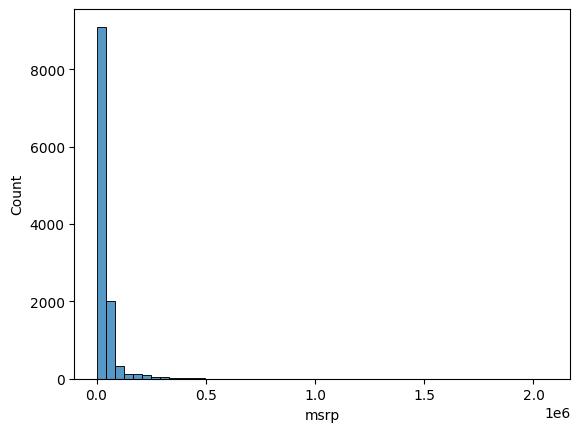

In [145]:
sns.histplot(df.msrp, bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

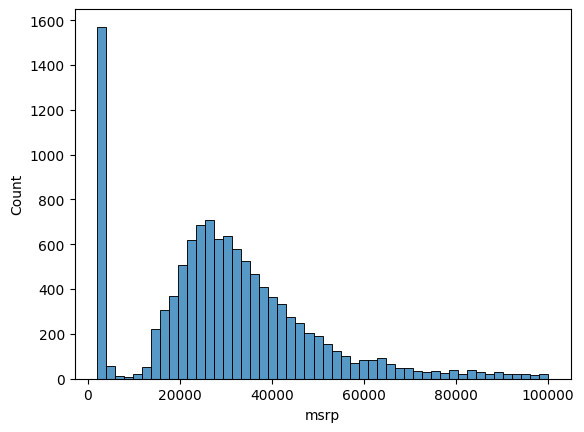

In [146]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)

In [147]:

"""
    Based on the previous plots we can see that the dataset for the MSRP,
    doesent actually have a normal distribution. Instead it has a right-skewed bimodal distribution,
    so beacuse of ML Model's favorability towards
    normal distribution, we apply the natural logarithmic function to all values.
    
    In which case we get a normal distribution.
"""

price_logarithmic = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

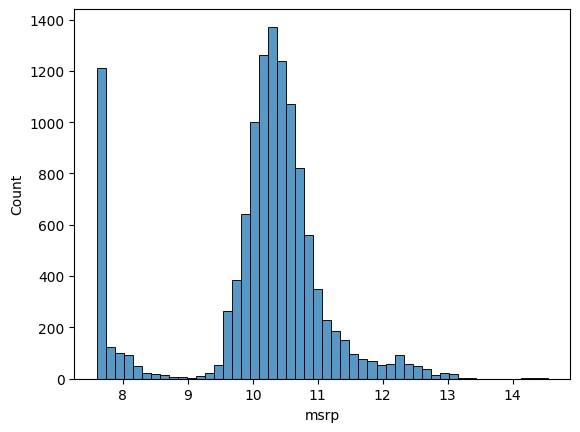

In [148]:
sns.histplot(price_logarithmic, bins=50)

In [149]:
"""
    The spike that we see at the beginning of the histogram is suspicious.
    Below in those couple of buckets in the range of the exponent e^x,
    where: 
    x1=7.5
    x2=8.2
    we can see we have a value of 2000 that is repeated exactly 1036 times.
    
    This almost certainly a placeholder value. One reson for this could be that those are,
    older cars where a recorded MSRP doesent exist. Lets check next where
    those 1036 records for a value of 2000 comes from.
"""



# Isolating whatever rows fall into the spike at the beginning
low_price_mask = (df['msrp'] > np.exp(7.5)) & (df['msrp'] < np.exp(8.2))
print(df[low_price_mask]['msrp'].value_counts().head(10))
print(df[low_price_mask][['make', 'model']].value_counts().head(10))

msrp
2000    1036
2107       4
2080       3
2234       3
2122       3
2078       3
3214       3
2637       3
2996       3
2066       3
Name: count, dtype: int64
make           model          
chevrolet      c/k_1500_series    53
ford           f-250              41
dodge          ram_150            40
mazda          b-series_pickup    37
chevrolet      s-10_blazer        31
mercedes-benz  300-class          27
volvo          850                26
toyota         pickup             26
dodge          ram_250            25
saab           900                23
Name: count, dtype: int64


In [150]:
"""
    We can see that that is indeed true, the fact that those cars are older models who probably
    didnt have a recorded MSRP. We can see that 75% of the 1036 rows fall into the category of
    cars being 1995 model or earlier.
    
    With this we have a couple of options:

     -Option One:
        Is to label it as NaN and later drop all of those 1036 values
    
    - Option Two:
        Is to use `Data Imputation via model prediction`. The way to do this would be
        to find data within the dataset that is similar to the placeholder data(the 1036 values)
        and to use a model to find the approximate value for those placeholder data rows.
        
        The problem with this for our dataset is it wont be accurate. If we take a car model
        that is 2015 with similar or exact features as a car from the missing placeholder data,
        say that is 1995 model, our regression system wont take into the account other variables,
        such as inflation, branding and other variables.
        
        The other problem with this is we would be guessing with no real baseline price,
        and this could introduce later a bias/noise into the rest of the data which would
        lower the accuracy of the model overall.
        
"""


print(df[df['msrp'] == 2000]['year'].describe())

count    1036.000000
mean     1993.441120
std         2.449767
min      1990.000000
25%      1992.000000
50%      1993.000000
75%      1995.000000
max      2000.000000
Name: year, dtype: float64


In [151]:
df.loc[df['msrp'] == 2000, 'msrp'] = np.nan

print(f"Flagged {df['msrp'].isna().sum()} rows as missing MSRP")
print(df['msrp'].isna().sum(), "out of", len(df), "total rows")

Flagged 1036 rows as missing MSRP
1036 out of 11914 total rows
